<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/avcad_ex8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Agglomerative Cluster Analysis using the EFIplus_medit dataset

###1. Import libraries and dataset

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Import dataset
EFI = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')

###2. Data preparation

***prompt***: select sites from the Douro and Tejo basins, keep quantitative environmental variables used previously, remove missing values, standardize the variables, and inspect the resulting dataframe for hierarchical clustering analysis

In [11]:
# Select sites from Douro and Tejo basins
EFI = EFI[(EFI['Catchment_name'] == 'Douro') |
          (EFI['Catchment_name'] == 'Tejo')]

# Select quantitative environmental variables
env_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

df = EFI[env_vars].dropna()

# Standardize variables
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

# Convert back to dataframe
df_scaled = pd.DataFrame(df_scaled, columns=env_vars)

# Inspect dataframe
print(df_scaled.shape)

df_scaled.head()

(888, 7)


,Altitude,Actual_river_slope,Elevation_mean_catch,prec_ann_catch,temp_ann,temp_jan,temp_jul
0,1.977157,0.083440,1.819874,-0.568930,-1.884845,-1.844771,-1.456903
1,1.703876,-0.126266,1.758331,-0.594745,-1.528436,-1.628612,-1.121913
2,1.478000,-0.189680,1.695256,-0.621683,-1.528436,-1.628612,-1.169769
3,1.321839,-0.003937,1.661725,-0.635268,-1.439333,-1.448480,-0.930491
4,1.213084,-0.478288,1.548328,-0.686126,-1.305680,-1.412454,-0.834779


The environmental variables were standardized before clustering because hierarchical clustering methods are sensitive to variable scales. Standardization ensures that variables with larger numerical ranges do not dominate the distance calculations.

###3. Agglomerative cluster analysis using different linkage methods

####Single Linkage Dendogram

***prompt***: run agglomerative hierarchical clustering using single linkage and plot the dendrogram to evaluate site similarity patterns

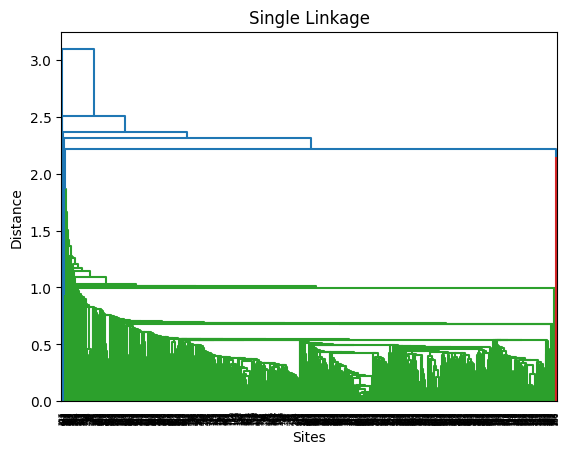

In [12]:
# Single linkage
dendrogram_plot = dendrogram(linkage(df_scaled, method='single'))

plt.title('Single Linkage')
plt.xlabel('Sites')
plt.ylabel('Distance')

plt.show()

Single linkage tends to produce elongated clusters due to the chaining effect, where observations are linked through nearest neighbors. This often results in less compact and less distinct groups of sampling sites.

####Complete Linkage Dendrogram

***prompt***: run agglomerative hierarchical clustering using complete linkage and visualize the dendrogram for comparison with single linkage clustering

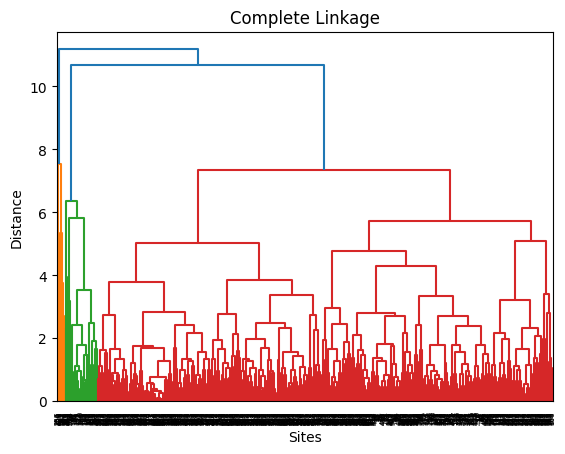

In [13]:
# Complete linkage
dendrogram_plot = dendrogram(linkage(df_scaled, method='complete'))

plt.title('Complete Linkage')
plt.xlabel('Sites')
plt.ylabel('Distance')

plt.show()

Complete linkage generated more compact and separated clusters compared with single linkage. This method uses the maximum distance between observations when forming clusters, reducing the chaining effect.

####Average Linkage Dendrogram

***prompt***: run agglomerative hierarchical clustering using average linkage and plot the dendrogram to identify intermediate clustering patterns among sites

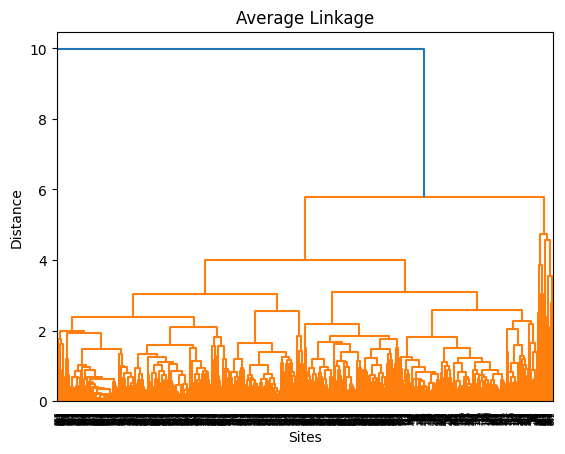

In [14]:
# Average linkage
dendrogram_plot = dendrogram(linkage(df_scaled, method='average'))

plt.title('Average Linkage')
plt.xlabel('Sites')
plt.ylabel('Distance')

plt.show()

Average linkage produced clusters that were more balanced than single linkage while remaining less restrictive than complete linkage. This method is often considered a compromise between cluster compactness and flexibility.

####Centroid Linkage Dendrogram

***prompt***: run agglomerative hierarchical clustering using centroid linkage and visualize the dendrogram based on centroid distances among clusters

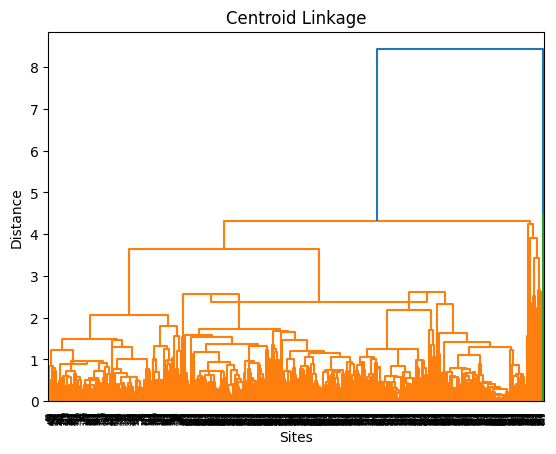

In [15]:
# Centroid linkage
dendrogram_plot = dendrogram(linkage(df_scaled, method='centroid'))

plt.title('Centroid Linkage')
plt.xlabel('Sites')
plt.ylabel('Distance')

plt.show()

Centroid linkage groups clusters according to distances between their centroids. This approach may produce smoother cluster transitions, although it can sometimes create inversions in the dendrogram structure.

####Ward Linkage Dendrogram

***prompt***: run agglomerative hierarchical clustering using ward linkage and plot the dendrogram to identify compact environmental clusters among sites

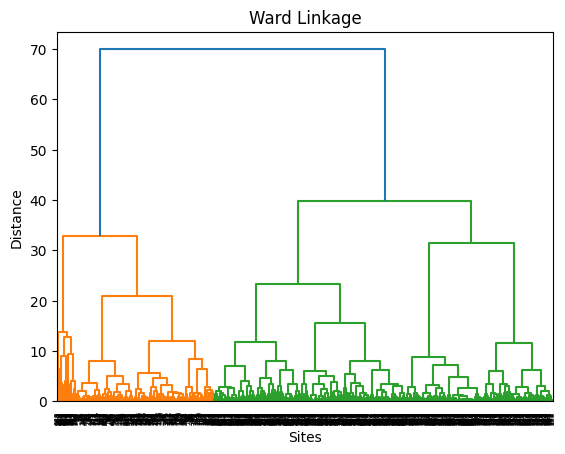

In [16]:
# Ward linkage
dendrogram_plot = dendrogram(linkage(df_scaled, method='ward'))

plt.title("Ward Linkage")
plt.xlabel('Sites')
plt.ylabel('Distance')

plt.show()

Ward linkage produced the most compact and homogeneous clusters because it minimizes within-cluster variance during cluster formation. This method is commonly preferred for ecological datasets containing continuous environmental variables.

###4. Improved average linkage dendrogram

***prompt***: run average linkage hierarchical clustering using manhattan distance and plot a horizontal truncated dendrogram with a distance threshold line for improved visualization of site clusters

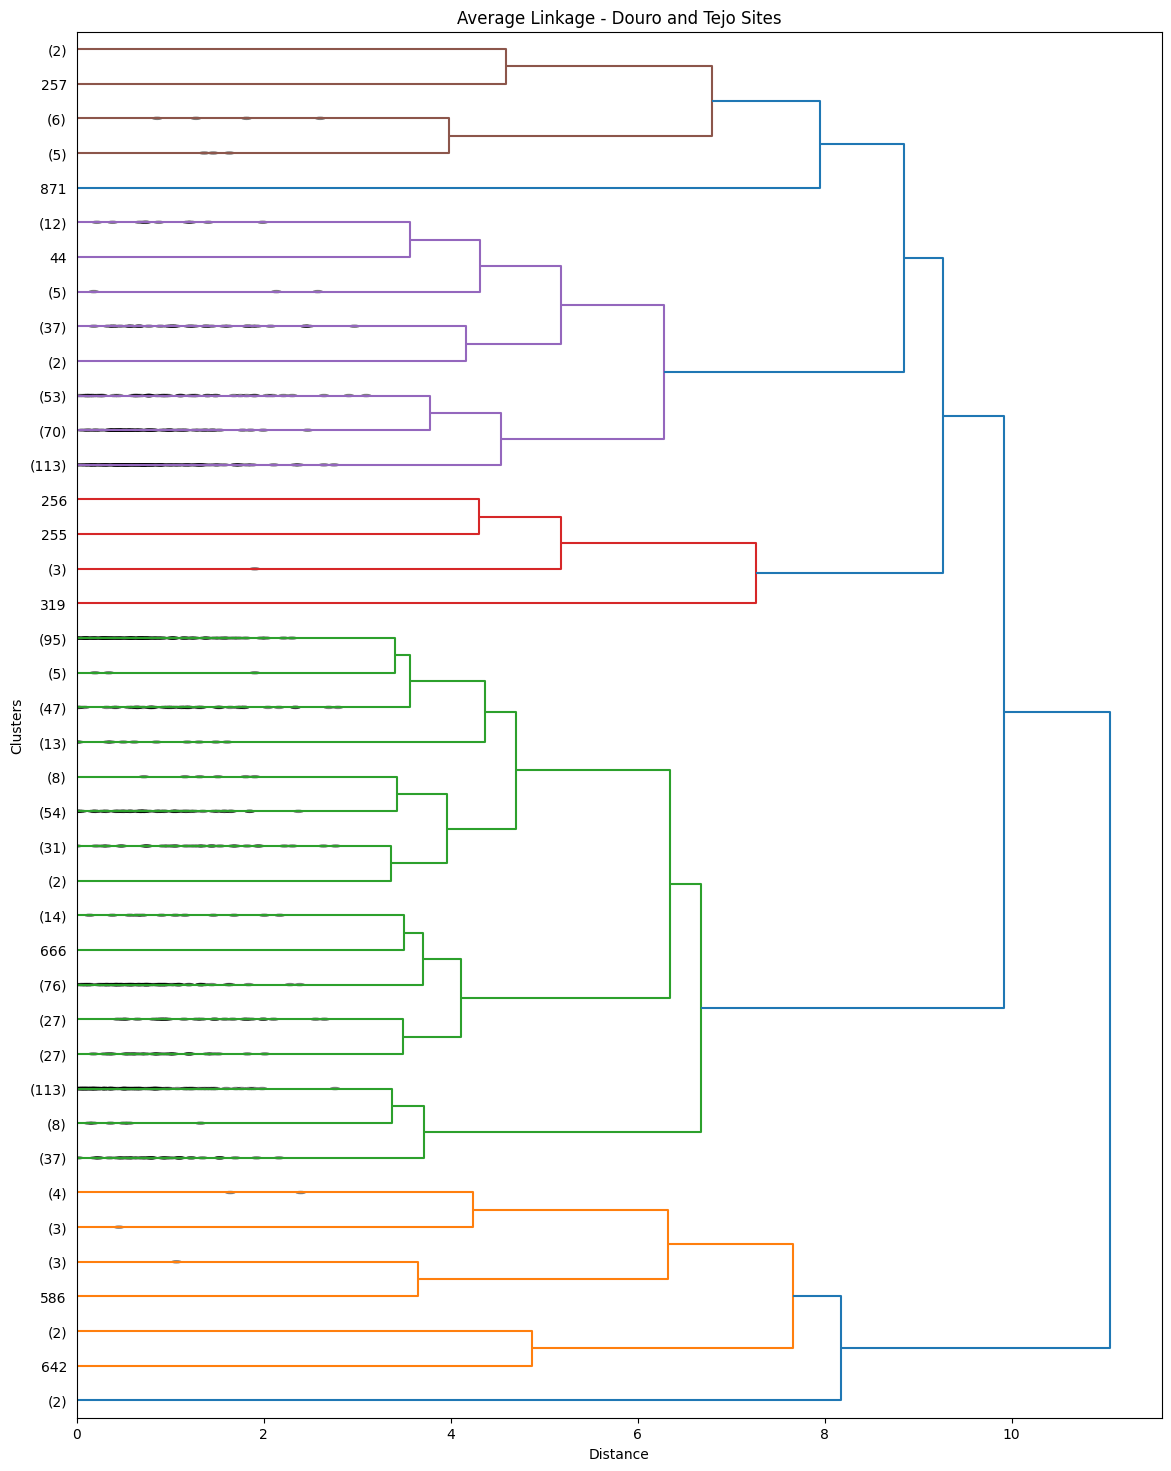

In [17]:
# Run linkage
link_avg = linkage(
    df_scaled,
    metric='cityblock',
    method='average'
)

# Plot dendrogram
plt.figure(figsize=(14, 18))

dendrogram_plot = dendrogram(
    link_avg,
    truncate_mode='lastp',
    p=40,
    leaf_font_size=10,
    show_contracted=True,
    orientation='right'
)

plt.title('Average Linkage - Douro and Tejo Sites')
plt.xlabel('Distance')
plt.ylabel('Clusters')

# Distance threshold
plt.axvline(x=15, color='red', linestyle='--')

plt.show()

The truncated dendrogram improves readability by displaying only the most relevant cluster merges. The vertical threshold line helps identify potential cluster partitions among sampling sites from the Douro and Tejo basins.

###5. Heatmap and dendrogram of sites

***prompt***: create a clustermap combining a heatmap and a dendrogram by clustering sampling sites with average linkage while maintaining environmental variables as fixed columns

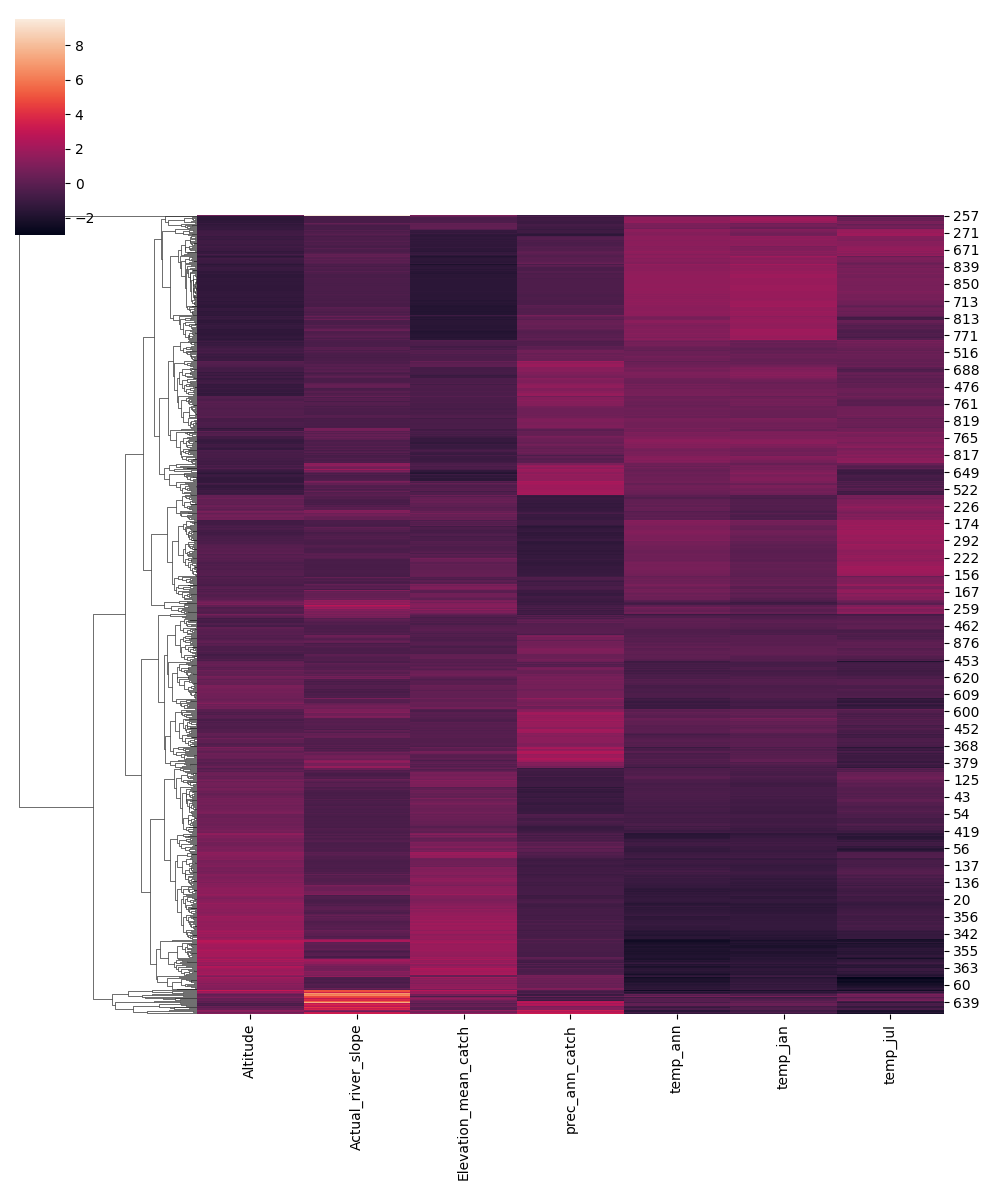

In [18]:
# Heatmap with row clustering
sns.clustermap(
    df_scaled,
    row_cluster=True,
    col_cluster=False,
    method='average',
    figsize=(10, 12)
)

plt.show()

The clustermap simultaneously displays environmental gradients and site similarity patterns. Sites grouped together in the dendrogram tend to share similar environmental conditions across the selected variables.

###6. Clustering environmental variables

***prompt***: transpose the standardized environmental dataframe and plot a dendrogram clustering the variables using average linkage to evaluate similarities among predictors

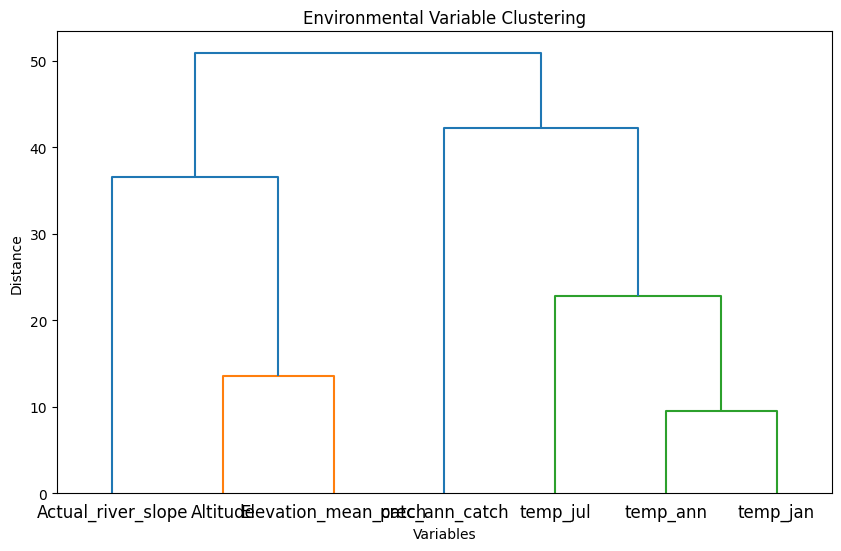

In [19]:
# Transpose dataframe
df_transposed = df_scaled.T

# Run linkage on variables
link_vars = linkage(
    df_transposed,
    method='average'
)

# Plot dendrogram
plt.figure(figsize=(10, 6))

dendrogram(
    link_vars,
    labels=df_transposed.index
)

plt.title('Environmental Variable Clustering')
plt.xlabel('Variables')
plt.ylabel('Distance')

plt.show()

Variables clustered closely together are likely to represent similar environmental gradients and may contain redundant information. This analysis is useful for identifying correlated predictors before regression modeling.

**Conclusion**

Clustering environmental variables helps identify groups of highly similar predictors that may introduce multicollinearity into regression models. Selecting representative variables from each cluster can improve model interpretability, reduce redundancy, and produce more stable ecological models.